In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
abdallahwagih_mall_customers_segmentation_path = kagglehub.dataset_download('abdallahwagih/mall-customers-segmentation')

print('Data source import complete.')


Using Colab cache for faster access to the 'mall-customers-segmentation' dataset.
Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mall-customers-segmentation/Mall_Customers.csv


In [3]:
import os

# Load dataset
df = pd.read_csv(os.path.join(abdallahwagih_mall_customers_segmentation_path, 'Mall_Customers.csv'))

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [5]:
df1=df.copy()

In [6]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()

In [7]:
X['Spending_Efficiency'] = X['Spending Score (1-100)'] / X['Annual Income (k$)']

In [57]:
X = X.drop(['Spending Score (1-100)', 'Annual Income (k$)'], axis=1)

In [58]:
print(X)

     Age  Spending_Efficiency
0     19             2.600000
1     21             5.400000
2     20             0.375000
3     23             4.812500
4     31             2.352941
..   ...                  ...
195   35             0.658333
196   45             0.222222
197   32             0.587302
198   32             0.131387
199   30             0.605839

[200 rows x 2 columns]


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

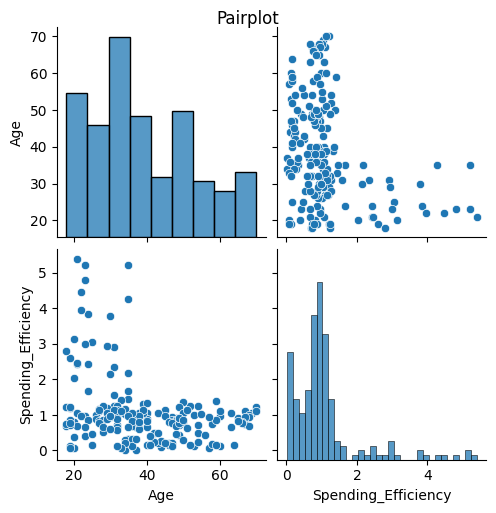

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(X)
plt.suptitle("Pairplot",y=1.01)
plt.show()

In [61]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

In [62]:
for k, score in zip(K_range, sil_scores):
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.420
K=3, Silhouette Score=0.502
K=4, Silhouette Score=0.409
K=5, Silhouette Score=0.427
K=6, Silhouette Score=0.385
K=7, Silhouette Score=0.403
K=8, Silhouette Score=0.449
K=9, Silhouette Score=0.435


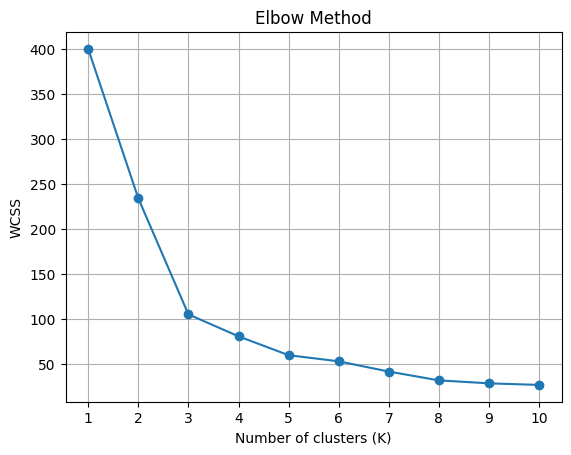

In [63]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [65]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [66]:
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,54.039474,57.486842,36.184211
1,30.442308,70.028846,55.182692
2,24.850000,23.000000,77.550000


In [67]:
cluster_profile_sorted = cluster_profile.sort_values(by=['Annual Income (k$)'], ascending=True)
print(cluster_profile_sorted)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
2        24.850000           23.000000               77.550000
0        54.039474           57.486842               36.184211
1        30.442308           70.028846               55.182692


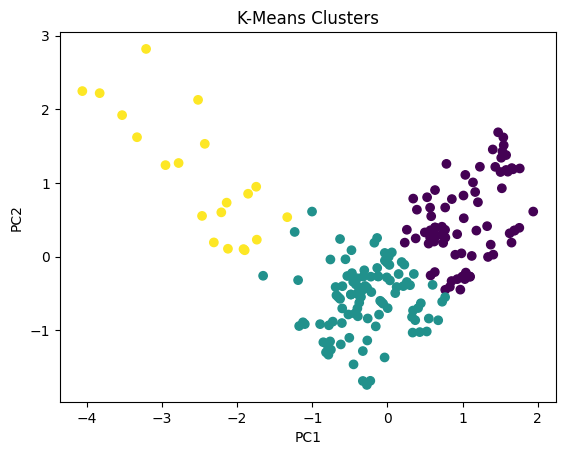

In [68]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

import matplotlib.pyplot as plt

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'])
plt.title("K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()